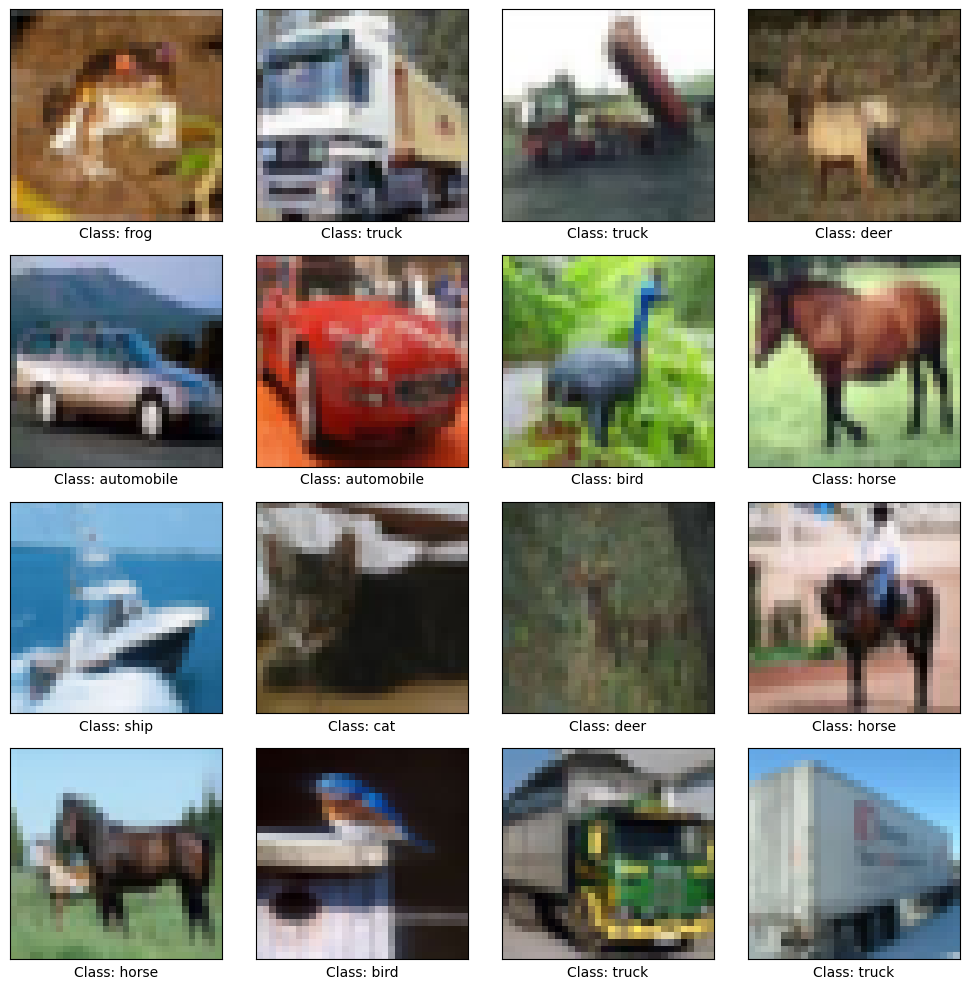

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 42ms/step - accuracy: 0.4347 - loss: 1.5522 - val_accuracy: 0.5180 - val_loss: 1.3261
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.5794 - loss: 1.1849 - val_accuracy: 0.5934 - val_loss: 1.1350
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.6322 - loss: 1.0436 - val_accuracy: 0.6389 - val_loss: 1.0368
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.6658 - loss: 0.9529 - val_accuracy: 0.6531 - val_loss: 0.9873
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.6895 - loss: 0.8853 - val_accuracy: 0.6746 - val_loss: 0.9281
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 40ms/step - accuracy: 0.7077 - loss: 0.8318 - val_accuracy: 0.6830 - val_loss: 0.8989
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.7254 - loss: 0.7886 - val_accuracy: 0.6826 - val_loss: 0.9194
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.7386 -

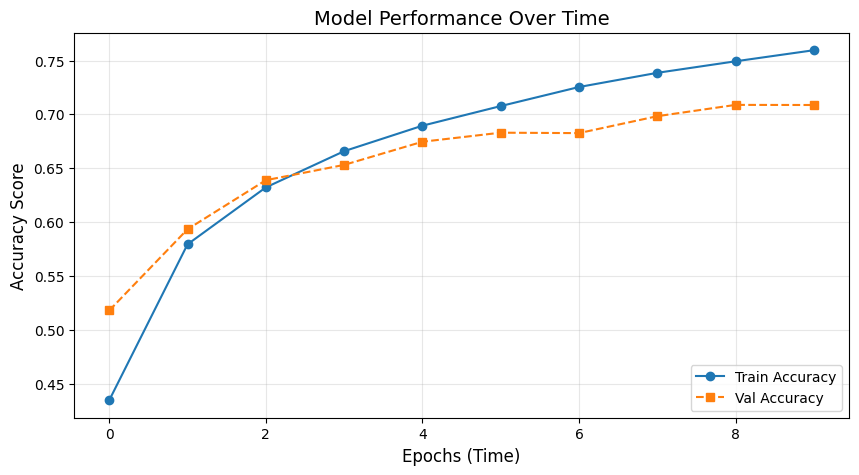

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


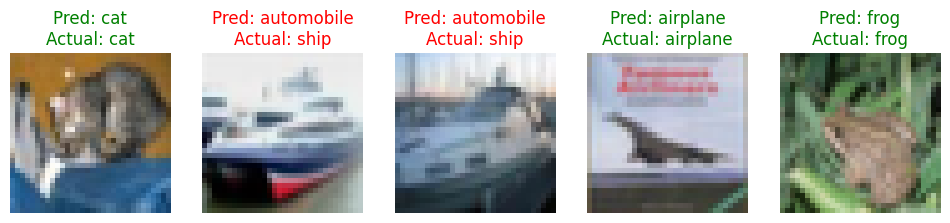

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


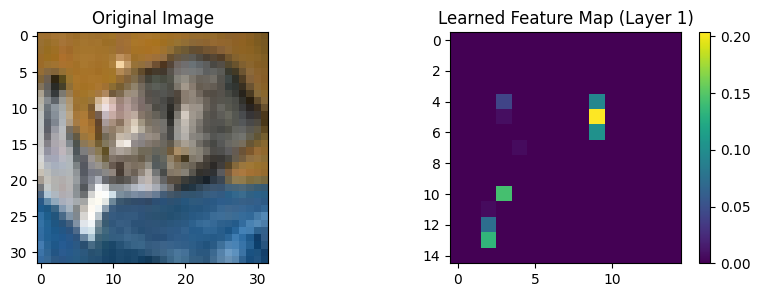


--- Tutorial Script Complete ---


In [3]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# 2. DATASET PREPARATION & NORMALIZATION
# Teaching Point: CNNs perform better when data is "scaled."
# We scale pixel values (0-255) to a range of (0-1).
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 3. ACCESSIBLE DATA VISUALIZATION
# Grading Tip: We use clear titles and a grid layout to introduce the data.
plt.figure(figsize=(10,10))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The [0] is because CIFAR labels are in a 2D array
    plt.xlabel(f"Class: {class_names[train_labels[i][0]]}", fontsize=10)
plt.tight_layout()
plt.show()

# 4. BUILDING THE ARCHITECTURE
def build_model():
    model = models.Sequential([
        # FIX: Explicitly define the input shape here
        layers.Input(shape=(32, 32, 3)),

        # Block 1: Feature Extraction
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Block 2: Learning more complex patterns
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Block 3: High-level features
        layers.Conv2D(64, (3, 3), activation='relu'),

        # Classification Head
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10)
    ])
    return model

# Instantiate the model
model = build_model()

# 5. COMPILING THE MODEL
# We use 'Adam' because it is an adaptive learning rate optimizer.
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.summary() # Essential for technical clarity

# 6. TRAINING THE MODEL
# We run for 10 epochs. In a tutorial, we show progress over time.
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

# 7. ACCESSIBLE RESULTS PLOT (Color-Blind Friendly)
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy',
         linestyle='-', marker='o', color='#1f77b4') # Blue with circles
plt.plot(history.history['val_accuracy'], label='Val Accuracy',
         linestyle='--', marker='s', color='#ff7f0e') # Orange with squares

plt.title('Model Performance Over Time', fontsize=14)
plt.xlabel('Epochs (Time)', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# 8. PREDICTION & ERROR ANALYSIS
# Teaching Point: A good tutorial shows where the model fails.
predictions = model.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)

def plot_analysis(num_images=5):
    plt.figure(figsize=(12, 4))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(test_images[i])
        actual = class_names[test_labels[i][0]]
        pred = class_names[predicted_classes[i]]

        # Highlight errors in red, correct in green
        color = 'green' if actual == pred else 'red'
        plt.title(f"Pred: {pred}\nActual: {actual}", color=color)
        plt.axis('off')
    plt.show()

plot_analysis()

# 9. FEATURE MAP VISUALIZATION (Mastery Level)
# This reveals the "Black Box" of AI by showing what a filter detects.
layer_outputs = [layer.output for layer in model.layers[1:5]] # Start from index 1 to skip Input layer
activation_model = models.Model(inputs=model.inputs[0], outputs=layer_outputs)

# Take one image and see its internal activations
img = test_images[0].reshape(1, 32, 32, 3)
activations = activation_model.predict(img)

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.imshow(test_images[0])
plt.title("Original Image")

plt.subplot(1, 2, 2)
# Visualizing the 1st filter of the 1st layer (often looks like edges)
plt.imshow(activations[0][0, :, :, 0], cmap='viridis')
plt.title("Learned Feature Map (Layer 1)")
plt.colorbar()
plt.show()

print("\n--- Tutorial Script Complete ---")